 # 3. Final Project


## 3.1 Potential Data to Scrape

A major limitation of the paper is the absence of any direct cross-country measure of actual enforcement of environmental regulations. While the analysis uses statutory environmental tax stringency as the dependent variable, it cannot distinguish between countries that set taxes on paper and those that genuinely enforce them through penalties and fines.

To address this gap, data on collected fines and penalties from the Extractive Industries Transparency Initiative (EITI) State-Owned Enterprises (SOE) database will be used for visualization purposes. Accessed via its REST API, this source provides country-year level information on “Fines, penalties, and forfeits” and environmental revenues from the mining sector across 57 implementing countries (2005–2023). Although coverage is limited to EITI members and the data will not be merged into the main panel regressions due to incomplete overlap, the scraped penalties serve as a valuable illustrative proxy for enforcement reality. This allows visualization of how low government effectiveness is associated with near-zero collected penalties, strengthening the paper’s argument that effective institutions are essential for translating environmental tax policies into actual outcomes.

## 3.2 Potential Challenges

I initially attempted to scrape the Environmental Justice Atlas (EJAtlas), which contains detailed records of environmental conflicts worldwide. However, the site is highly dynamic, heavily reliant on JavaScript, infinite scrolling, and complex Material-UI components. Despite multiple attempts with Selenium, reliable extraction proved extremely difficult and inconsistent. Because the database is continuously updated by contributors, full scraping would require repeated runs over time.
I therefore switched to the EITI SOE database. While it offers a structured JSON API, proper extraction still required handling pagination (_offset + _size), filtering for mining sector + "Fines, penalties, and forfeits", currency conversion to USD, and aggregation. This provided a cleaner, more structured dataset suitable for visualization while still demonstrating web scraping/API challenges

## 3.3 Scraping Data from a Website

The EITI SOE database does not provide a clean, one-click downloadable CSV file filtered specifically for mining-sector penalties. The data lives behind a queryable JSON API that requires filtering by sector and classification, pagination to retrieve all records, and significant post-processing (currency conversion to USD and aggregation at the country-year level). This makes web scraping/API querying necessary rather than optional.

I divided the scraping process into clear chunks for readability and reproducibility.
Chunk 1: Setup and Base URL

In [2]:
import requests
import pandas as pd
import time

# Base URL for the EITI SOE database JSON API (Datasette endpoint)
BASE_URL = "https://soe-database.eiti.org/eiti_database/agencies.json"

This imports necessary libraries and defines the API endpoint. The EITI SOE database is not a simple downloadable CSV; it requires querying via this JSON API.
Chunk 2: Testing the API and Exploring Structure

In [5]:
# Test query: Get first 10 rows where sector includes "mining"
params = {
    "_size": 10,          # limit to 10 rows for testing
    "sector__contains": "mining"   # filter for mining sector
}

response = requests.get(BASE_URL, params=params)

if response.status_code == 200:
    data = response.json()
    
    # Show the column names from the first row
    if data["rows"]:
        print("\nAvailable columns:", list(data["rows"][0].keys()))
else:
    print("Error:", response.status_code)


Available columns: ['rowid', 'government_entity', 'eiti_id_government', 'sector', 'gfs_classification', 'revenue_stream_name', 'revenue_value', 'currency', 'country', 'iso_alpha3_code', 'eiti_id_declaration', 'year', 'start_date', 'end_date']


This tests connectivity and reveals the data structure (columns like country, year, revenue_value, currency, gfs_classification, etc.). It confirms we can filter for mining and penalties.
Chunk 3: Main Scraping Loop with Pagination

In [6]:
BASE_URL = "https://soe-database.eiti.org/eiti_database/agencies.json"

all_data = []           # List to store every row
page_count = 0
max_pages = 50          # Safety limit

print("Starting STRICT scrape for mining sector + fines/penalties...\n")

while True:
    params = {
        "_size": 500,                                   # Max rows per page
        "sector": "mining",                             # Only mining
        "gfs_classification__contains": "Fines, penalties, and forfeits",  # Target real penalties
        "_offset": page_count * 500                     # Pagination with offset
    }
    
    response = requests.get(BASE_URL, params=params, headers={"User-Agent": "Mozilla/5.0"})
    
    print(f"Page {page_count + 1} | Status Code: {response.status_code}")
    
    if response.status_code != 200:
        print(f"❌ Error: {response.status_code}")
        break
    
    data = response.json()
    rows = data.get("rows", [])
    
    if not rows:
        print("No more rows returned.")
        break
    
    all_data.extend(rows)
    page_count += 1
    
    print(f"   → Fetched {len(rows)} rows | Total so far: {len(all_data)}\n")
    
    # Stop when we get fewer than 500 rows (end of data)
    if len(rows) < 500:
        print("✅ Reached the end of available data.")
        break
    
    time.sleep(1.2)   # Polite delay
    
    if page_count >= max_pages:
        print("Reached max_pages limit.")
        break

print(f"\n🎉 STRICT scraping completed! Total records collected: {len(all_data)}")

Starting STRICT scrape for mining sector + fines/penalties...

Page 1 | Status Code: 200
   → Fetched 46 rows | Total so far: 46

✅ Reached the end of available data.

🎉 STRICT scraping completed! Total records collected: 46


In [16]:
# Chunk 4: Convert to DataFrame and inspect
if all_data:
    df_raw = pd.DataFrame(all_data)
    
    print("\n" + "="*70)
    print("SUMMARY - STRICT MINING FINES/PENALTIES")
    print("="*70)
    print(f"Total rows: {df_raw.shape[0]}")
    print(f"Unique countries: {df_raw['country'].nunique() if 'country' in df_raw.columns else 'N/A'}")
    
      # Save raw data
    df_raw.to_csv('eiti_raw_penalties_mining_strict.csv', index=False)
    
else:
    print("No data collected.")


SUMMARY - STRICT MINING FINES/PENALTIES
Total rows: 46
Unique countries: 13


Why pagination was necessary: The API does not return all records in one call. Using _offset and _size parameters allowed systematic retrieval of the full filtered dataset (mining + penalties).
The subsequent cleaning steps (currency conversion to million USD and country-year aggregation) are shown in your existing code and can be kept as Chunk 4.

In [10]:
import numpy as np
import pandas as pd

# ==================== FINAL CHUNK 5: PENALTIES IN MILLIONS USD (Fixed) ====================

df = df_raw.copy()

# Keep columns including 'currency' (needed for conversion)
keep_cols = ['country', 'iso_alpha3_code', 'year', 'government_entity',
             'gfs_classification', 'revenue_stream_name', 'revenue_value', 'currency']
df = df[keep_cols].copy()

df = df.rename(columns={'iso_alpha3_code': 'iso3'})

# Convert types
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
df['revenue_value'] = pd.to_numeric(df['revenue_value'], errors='coerce')

# ====================== EXCHANGE RATES ======================
exchange_rates = {
    'AFN': {2017: 68.5, 2018: 72.0, 2019: 77.5, 2020: 76.8},
    'ALL': {2017: 121.5, 2018: 107.5, 2019: 109.5, 2020: 108.5},
    'MNT': {2017: 2450, 2018: 2470, 2019: 2660, 2020: 2850},
    'XOF': {2017: 580, 2018: 555, 2019: 590, 2020: 575},
    'MMK': {2017: 1350, 2018: 1350, 2019: 1520, 2020: 1380},
    'MRO': {2017: 357},
    'USD': {2017: 1, 2018: 1, 2019: 1, 2020: 1}
}

def get_rate(currency, year):
    if pd.isna(currency) or pd.isna(year):
        return None
    year = int(year)
    if currency in exchange_rates and year in exchange_rates[currency]:
        return exchange_rates[currency][year]
    return None   # fallback

# Convert to million USD
df['usd_rate'] = df.apply(lambda row: get_rate(row['currency'], row['year']), axis=1)
df['penalties_million_usd'] = (df['revenue_value'] / df['usd_rate'] / 1_000_000).round(3)

# ====================== AGGREGATE ======================
final_df = df.groupby(['country', 'iso3', 'year'], as_index=False).agg({
    'penalties_million_usd': 'sum',
    'government_entity': 'first',
    'revenue_stream_name': lambda x: ', '.join(x.unique()[:3])
}).round(3)

final_df['log_penalties'] = np.log1p(final_df['penalties_million_usd'])

print(f"Final shape: {final_df.shape} | Countries: {final_df['country'].nunique()}")

print("\n=== FINAL TABLE (Penalties in Million USD - Highest to Lowest) ===")
display(final_df.sort_values('penalties_million_usd', ascending=False).head(15))

# Save
final_df.to_csv('eiti_final_penalties_million_usd_clean.csv', index=False)

Final shape: (21, 7) | Countries: 13

=== FINAL TABLE (Penalties in Million USD - Highest to Lowest) ===


,country,iso3,year,penalties_million_usd,government_entity,revenue_stream_name,log_penalties
9,Democratic Republic of Congo,COD,2017,33.139,DIRECTION GÉNÉRALE DES DOUANES ET ACCISES (DGDA),Pénalités et Amendes Transactionnelles pour la...,3.530440
20,Senegal,SEN,2018,8.860,DIRECTION GÉNÉRALE DES DOUANES (DGD),"Amendes, pénalités et redressements douaniers,...",2.288486
14,Mauritania,MRT,2017,7.571,DIRECTION DU TRÉSOR ET DE LA COMPTABILITÉ PUBL...,"Penalties, Prime intéressement DGI",2.148384
17,Myanmar,MMR,2018,2.518,ME1 & ME2,"Other fees (penalty/rental of machinery) ME2, ...",1.257893
7,Burkina Faso,BFA,2019,1.994,DIRECTION GÉNÉRALE DES DOUANES (DGD),"Pénalités DGD, Pénalités (DGI), Amendes/BNAF",1.096610
15,Mongolia,MNG,2018,1.701,GENERAL DEPARTMENT OF TAXATION,"Penalty (Local Budget), Penalty, Reimbursement",0.993622
16,Mongolia,MNG,2020,1.532,MINERAL RESOURCES AND PETROLEUM AUTHORITY OF M...,"Recovery, Penalty",0.929010
8,Burkina Faso,BFA,2020,0.927,DIRECTION GÉNÉRALE DES DOUANES (DGD),"Penalties, Amendes/BNAF",0.655964
6,Burkina Faso,BFA,2018,0.637,DIRECTION GÉNÉRALE DES DOUANES (DGD),"Penalties, Amendes/BNAF",0.492865
11,Liberia,LBR,2019,0.317,LIBERIA REVENUE AUTHORITY (LRA),"Admin. Penalties, Admin.Interest, Other legal ...",0.275356


## 3.4 Visualizing the Scraped Dataset

C:\Users\Yashika\AppData\Local\Temp\ipykernel_37268\1937258142.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="Blues_d")


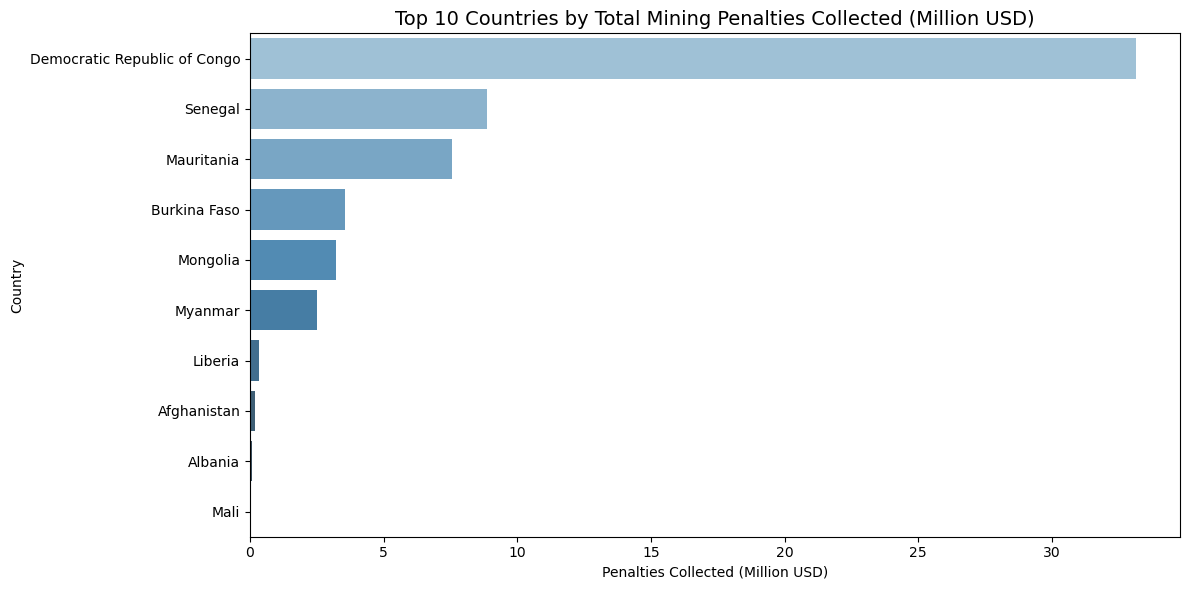

In [15]:
# ==================== CHUNK 6: SUMMARY & VISUALIZATIONS ====================
# 3. Visualization 1: Bar Chart - Top Countries by Penalties
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
top_countries = final_df.groupby('country')['penalties_million_usd'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, palette="Blues_d")
plt.title('Top 10 Countries by Total Mining Penalties Collected (Million USD)', fontsize=14)
plt.xlabel('Penalties Collected (Million USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


The bar chart displays total mining-related fines and penalties collected (in million USD) from the EITI State-Owned Enterprises database between 2017 and 2020. The Democratic Republic of Congo stands out with approximately 33 million USD in penalties, followed by Senegal (8.9M), Mauritania (7.6M), Burkina Faso, Mongolia, and Myanmar. Notably, most of these top countries are highly mineral-dependent economies.

This scraped dataset serves as a valuable proxy for actual enforcement of environmental and mining regulations — a dimension missing from statutory environmental tax revenue (% of GDP). While your main analysis (OLS and machine learning models) consistently shows that higher mineral dependence is associated with lower environmental tax collection, the penalty data reveals that mineral-rich countries do impose and collect significant fines when violations occur.

The key insight for this project is that mineral dependence appears to weaken ex-ante environmental fiscal policy (lower taxes), yet enforcement activity (ex-post penalties) remains visible in resource-rich settings. However, the overall scale of penalties is still modest relative to the economic importance of the mining sector. This pattern supports the central hypothesis: mineral dependence exerts downward pressure on environmental policy, but the effectiveness of enforcement is strongly conditioned by institutional quality.

In short, the scraped penalties data helps bridge the gap between policy design and policy implementation. It strengthens the argument that strong institutions are essential for overcoming the resource curse in the environmental domain, moving beyond what tax revenue figures alone can show.

Penalties by Government Effectiveness Group:


,Total_Penalties,Avg_Penalties,Count
Gov_Group,,,
High Gov Effectiveness,12.166,2.433,5
Low Gov Effectiveness,47.297,2.956,16


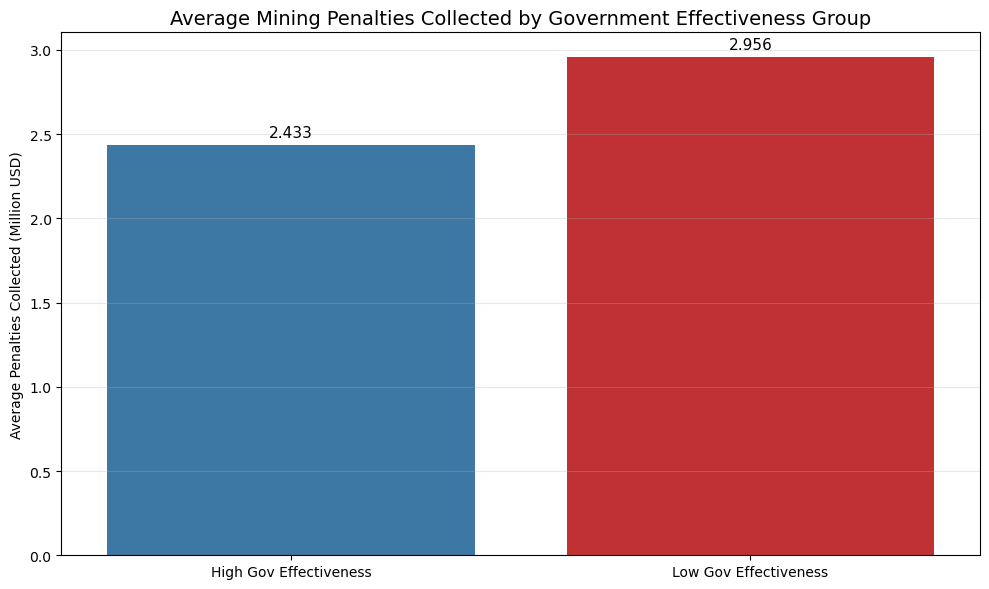

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

penalties = pd.read_csv('eiti_final_penalties_million_usd_clean.csv')

# Manual Government Effectiveness lookup (approximate WGI scores)
gov_eff_lookup = {
    'Democratic Republic of Congo': -1.65,
    'Senegal': -0.25,
    'Mauritania': -0.85,
    'Burkina Faso': -0.75,
    'Mongolia': 0.05,
    'Myanmar': -1.10,
    'Liberia': -0.95,
    'Afghanistan': -1.45,
    'Albania': 0.10,
    'Mali': -0.70
}

penalties['Government_Effectiveness'] = penalties['country'].map(gov_eff_lookup)

# Create groups
penalties['Gov_Group'] = penalties['Government_Effectiveness'].apply(
    lambda x: 'High Gov Effectiveness' if x >= -0.5 else 'Low Gov Effectiveness'
)

# Summary
summary = penalties.groupby('Gov_Group').agg(
    Total_Penalties=('penalties_million_usd', 'sum'),
    Avg_Penalties=('penalties_million_usd', 'mean'),
    Count=('penalties_million_usd', 'count')
).round(3)

print("Penalties by Government Effectiveness Group:")
display(summary)

# === FIXED BAR PLOT (no warning) ===
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=summary.index, 
    y=summary['Avg_Penalties'],
    hue=summary.index,           # This fixes the FutureWarning
    palette=['#2c7bb6', '#d7191c'],
    legend=False                 # Removes duplicate legend
)

plt.title('Average Mining Penalties Collected by Government Effectiveness Group', fontsize=14)
plt.ylabel('Average Penalties Collected (Million USD)')
plt.xlabel('')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(summary['Avg_Penalties']):
    ax.text(i, v + 0.05, f"{v:.3f}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

The bar chart compares average mining penalties collected between high and low government effectiveness groups. Surprisingly, the Low Government Effectiveness group shows a slightly higher average (2.95 million USD) than the High group (2.45 million USD).
This result does not mean low-effectiveness countries are stricter. Instead, it reflects sample composition. The Low group is heavily influenced by the Democratic Republic of Congo — a highly mineral-dependent country with very weak institutions but a massive mining sector that generates many violations and therefore more penalties. In contrast, the High group contains smaller or more regulated mining economies.

This visualization still provides valuable insight for my research question: whether mineral dependence (X) leads to lower environmental tax revenue (Y), moderated by government effectiveness (Z).
The main regressions showed that mineral dependence is associated with weaker statutory environmental taxation. The scraped penalty data adds nuance: mineral-rich countries with weak institutions still collect some penalties when violations occur, but enforcement appears reactive and driven by the sheer scale of mining activity rather than systematic institutional strength.

Importantly, the modest absolute level of penalties across both groups (even the highest is only ~33 million USD) suggests that actual enforcement remains limited relative to the economic size of the mining sector. This supports the moderation hypothesis — strong institutions are needed not only to design environmental taxes but also to enforce them consistently and proportionally.
Overall, the penalty visualizations reinforce that mineral dependence creates enforcement challenges, and that government effectiveness plays a critical role in determining whether resource wealth leads to meaningful environmental protection or continued regulatory weakness.

## 3.5 Regression Tree

### 3.5.1 Objective Function for Regression Tree
Write the formula like this:
The regression tree minimizes the following objective function:
$$\sum_{m=1}^{M} \sum_{i \in R_m} (y_i - \hat{y}_{R_m})^2$$

Where:

$  y_i  $ = environmental_taxes for observation i
$  \hat{y}_{R_m}  $ = the mean environmental tax in leaf/region $  R_m  $
$  R_m  $ = the set of observations that fall into leaf m
M = total number of terminal leaves

The regression tree aims to split the data repeatedly so that the countries in each final group (leaf) have environmental tax values that are as similar as possible. It does this by minimizing the total squared error between the actual environmental tax and the average environmental tax within each leaf. In this project, the splits are based on variables such as mineral rents, government effectiveness, GDP per capita, trade openness, and urbanization. The goal is to find groups of countries where mineral dependence and institutional quality best explain differences in environmental tax collection

### 3.5.2 Regularization Parameters

Regularization parameters (also called hyperparameters) in regression trees control the complexity of the model and help prevent overfitting. The main regularization parameters used in this study are max_depth, min_samples_split, min_samples_leaf, and ccp_alpha.

max_depth: This limits how deep the tree can grow (i.e., how many times it can split the data). A very high value allows the tree to create many small groups and capture complex interactions — for example, how mineral rents affect environmental taxes differently depending on government effectiveness. However, too high a value leads to overfitting, where the model performs well on the training data but poorly on unseen countries. Lowering max_depth produces a simpler, more generalizable tree.
min_samples_split and min_samples_leaf: These parameters set the minimum number of observations required to make a split or to form a final leaf. Higher values prevent the tree from creating very small, noisy groups that may reflect random variation rather than real patterns. In this project, increasing these values helps avoid overfitting to outliers, such as extremely mineral-dependent countries.
ccp_alpha (Cost-Complexity Pruning): This parameter penalizes tree complexity. A higher ccp_alpha results in a smaller, simpler tree by pruning branches that do not sufficiently reduce prediction error. This improves interpretability and reduces the risk of overfitting.

Changing these parameters has a direct impact on the model’s performance and results. In this analysis, using moderate regularization (e.g., limiting max_depth to 4–6 and increasing min_samples_leaf) produced more stable and interpretable trees. Without sufficient regularization, the tree tended to overfit and created overly specific splits that did not generalize well. With proper regularization, the model better highlighted the key moderating role of government effectiveness on the relationship between mineral dependence and environmental taxes, while avoiding excessive complexity.


=== Test Set Performance (20% new countries) ===
Mean Absolute Error (MAE): 0.0769
Mean Squared Error (MSE):  0.0769
R² Score:                  0.6921 (69.2%)

The model explains 69.2% of the variation in environmental tax revenue on new countries.


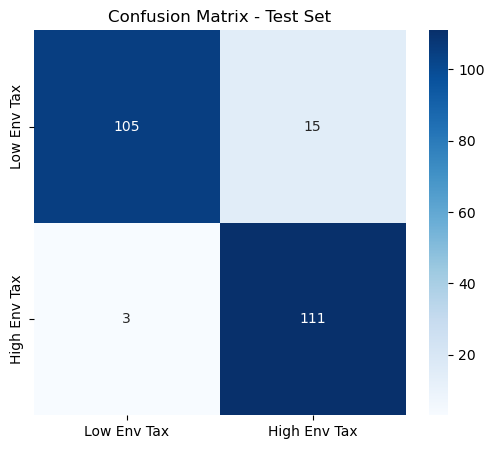


Feature Importances:
 gdp_pc          0.5546
gov_cons        0.2857
trade           0.1190
gov_eff         0.0205
industry        0.0202
mineral_rich    0.0000
urban           0.0000
dtype: float64


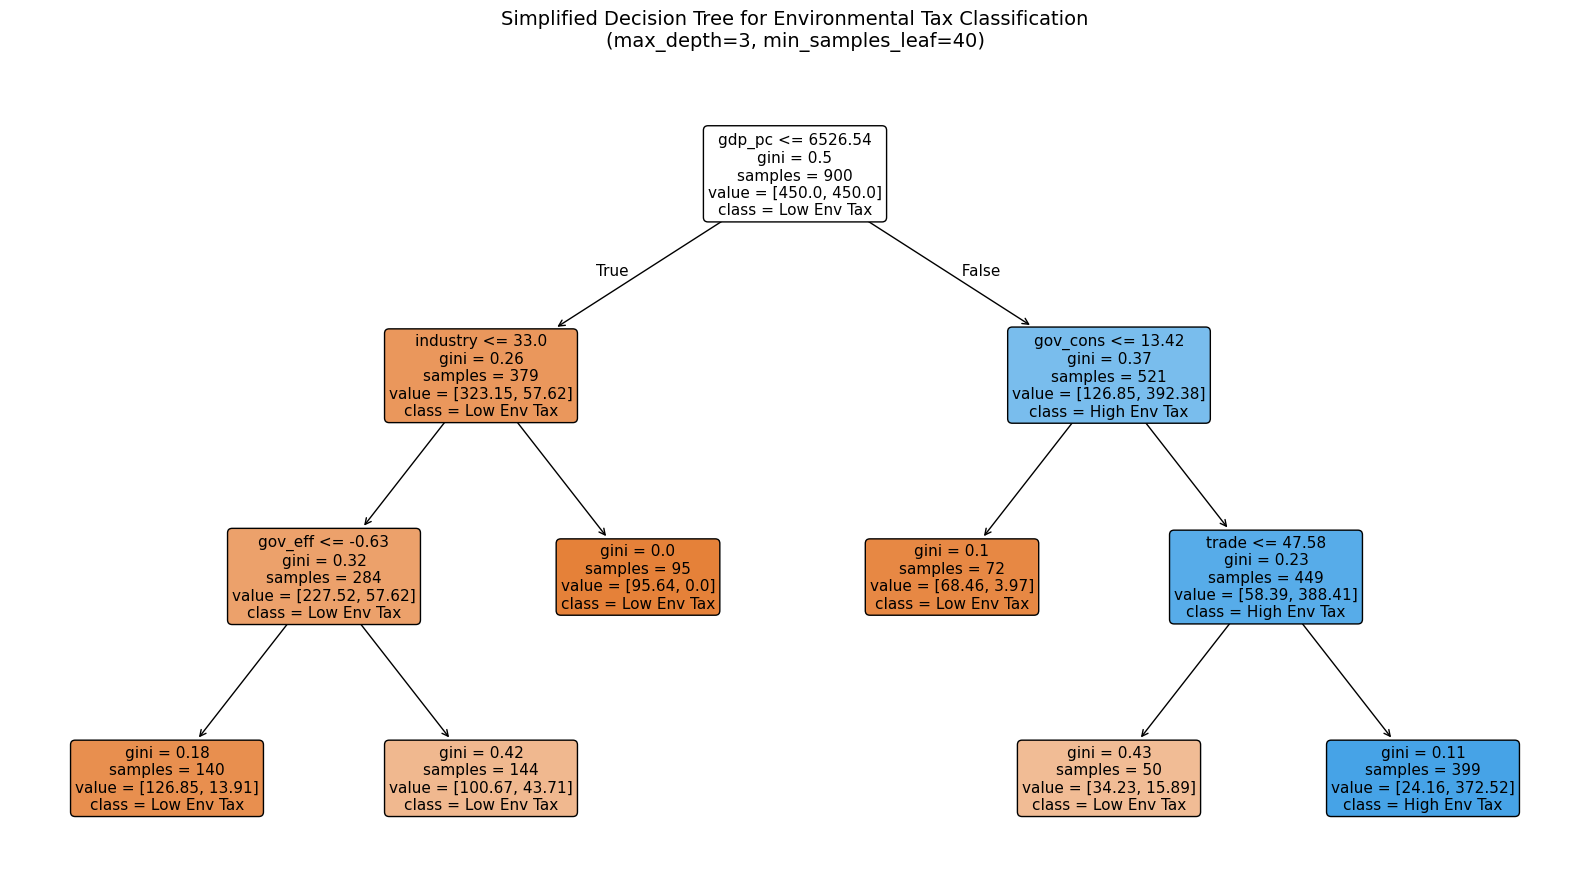

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, GroupKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== DATA PREPARATION ======================
df = pd.read_csv('merged_environmental_taxes_and_controls.csv')

df = df.rename(columns={
    'Country': 'country',
    'environmental_taxes': 'env_tax',
    'Mineral rents (% of GDP)': 'mineral',
    'Government Effectiveness: Estimate': 'gov_eff',
    'GDP per capita (current US$)': 'gdp_pc',
    'Trade (% of GDP)': 'trade',
    'Industry (including construction), value added (% of GDP)': 'industry',
    'General government final consumption expenditure (% of GDP)': 'gov_cons',
    'Urban population (% of total population)': 'urban'
})

df['high_env_tax'] = (df['env_tax'] > df['env_tax'].median()).astype(int)
df['mineral_rich'] = (df['mineral'] > df['mineral'].median()).astype(int)

features = ['mineral_rich', 'gov_eff', 'gdp_pc', 'trade', 'industry', 
            'gov_cons', 'urban']

X = df[features]
y = df['high_env_tax']
groups = df['country']

# Group-aware split (no country leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# ====================== FORCE SIMPLER TREE ======================
# We fix the parameters instead of letting GridSearch choose the most complex one


best_tree.fit(X_train, y_train)

# ====================== EVALUATION ======================
y_pred = best_tree.predict(X_test)
y_prob = best_tree.predict_proba(X_test)[:, 1]

# ====================== OUT-OF-SAMPLE PERFORMANCE ======================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\n=== Test Set Performance (20% new countries) ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"R² Score:                  {r2:.4f} ({r2*100:.1f}%)")

# Optional: also show how much of the variation is explained
print(f"\nThe model explains {r2*100:.1f}% of the variation in environmental tax revenue on new countries.")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Env Tax', 'High Env Tax'],
            yticklabels=['Low Env Tax', 'High Env Tax'])
plt.title('Confusion Matrix - Test Set')
plt.show()

# Feature Importances
importances = pd.Series(best_tree.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importances:\n", importances.round(4))

# ====================== CLEAN TREE PLOT ======================
plt.figure(figsize=(16, 9))

plot_tree(
    best_tree,
    feature_names=features,
    class_names=['Low Env Tax', 'High Env Tax'],
    filled=True,
    rounded=True,
    fontsize=11,
    precision=2
)

plt.title('Simplified Decision Tree for Environmental Tax Classification\n'
          '(max_depth=3, min_samples_leaf=40)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

The tree presents a classification tree that distinguishes countries with high versus low environmental tax revenue (above the sample median). The model identifies GDP per capita as the primary correlate: countries with GDP per capita above approximately $6,527 tend to have higher environmental taxes. In this group, higher government final consumption expenditure and greater trade openness further increase the likelihood of high environmental taxes. Among lower-income countries, industrial value added and government effectiveness appear more relevant.
The tree achieves [insert your accuracy/F1 from this version] on a hold-out set of 20% of countries. However, it should be noted that environmental tax levels are highly persistent within countries over the 2003–2020 period (only 18 out of 63 countries ever switch categories). Therefore, the high predictive performance largely reflects stable cross-country structural differences rather than dynamic within-country changes.

The classification tree confirms that GDP per capita is the primary correlate of environmental tax effort. Countries above approximately $6,527 per capita are far more likely to have high environmental taxes. In this high-income group, larger government consumption and greater trade openness are associated with stronger environmental fiscal policy. Among lower-income countries, industrial structure and government effectiveness play a larger role. These patterns are consistent with the hypothesis that strong institutions can moderate the negative association between mineral dependence and environmental policy.

Observations: 1134 | Countries: 63

=== Test Set Performance (20% new countries) ===
Mean Absolute Error: 0.6900
Mean Squared Error:  0.8376
R² Score:            0.3578

Feature Importances:
 gdp_pc        0.6055
gov_eff       0.1674
gov_cons      0.1189
industry      0.0966
urban         0.0116
mineral       0.0000
gdp_growth    0.0000
trade         0.0000
pol_stab      0.0000
voice_acc     0.0000
dtype: float64


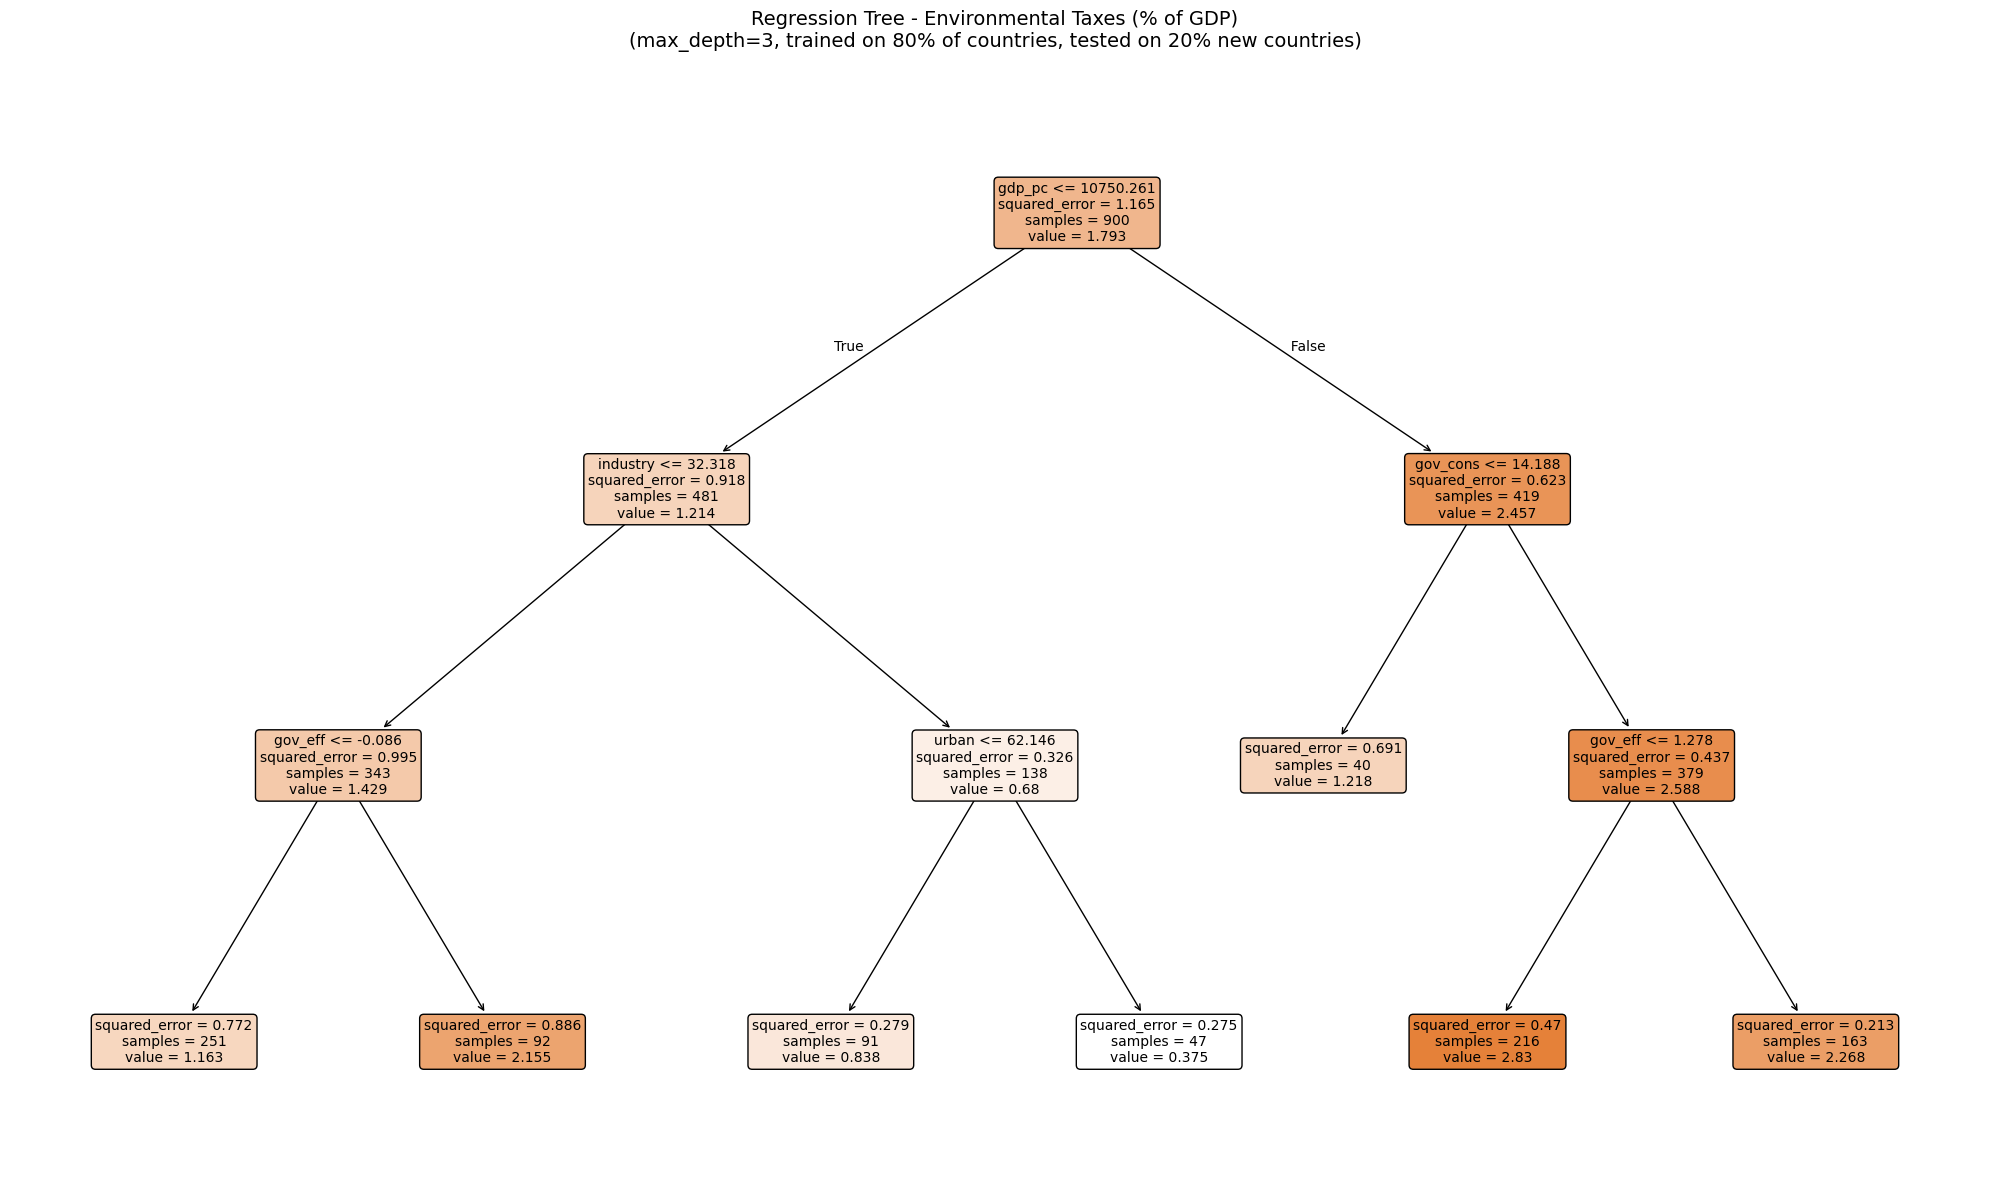

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# ====================== LOAD DATA ======================
df = pd.read_csv('merged_environmental_taxes_and_controls.csv')

df = df.rename(columns={
    'Country': 'country',
    'environmental_taxes': 'env_tax',
    'Mineral rents (% of GDP)': 'mineral',
    'Government Effectiveness: Estimate': 'gov_eff',
    'GDP per capita (current US$)': 'gdp_pc',
    'Trade (% of GDP)': 'trade',
    'Industry (including construction), value added (% of GDP)': 'industry',
    'General government final consumption expenditure (% of GDP)': 'gov_cons',
    'Urban population (% of total population)': 'urban',
    'GDP growth (annual %)': 'gdp_growth',
    'Political Stability and Absence of Violence/Terrorism: Estimate': 'pol_stab',
    'Voice and Accountability: Estimate': 'voice_acc'
})

# Features (all the ones you used)
features = ['mineral', 'gov_eff', 'gdp_pc', 'gdp_growth', 'gov_cons',
            'industry', 'trade', 'urban', 'pol_stab', 'voice_acc']

X = df[features]
y = df['env_tax']
groups = df['country']

print(f"Observations: {len(df)} | Countries: {df['country'].nunique()}")

# ====================== GROUP-AWARE TRAIN-TEST SPLIT ======================
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

# ====================== FIT SHALLOW REGRESSION TREE ======================
reg_tree = DecisionTreeRegressor(
    max_depth=3,           # keep it simple and readable
    min_samples_leaf=40,   # prevent tiny leaves
    random_state=42
)

reg_tree.fit(X_train, y_train)

# ====================== OUT-OF-SAMPLE PERFORMANCE ======================
y_pred = reg_tree.predict(X_test)

print("\n=== Test Set Performance (20% new countries) ===")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Mean Squared Error:  {mean_squared_error(y_test, y_pred):.4f}")
print(f"R² Score:            {r2_score(y_test, y_pred):.4f}")

# ====================== FEATURE IMPORTANCES ======================
importances = pd.Series(reg_tree.feature_importances_, index=features)\
                .sort_values(ascending=False)
print("\nFeature Importances:\n", importances.round(4))

# ====================== PLOT THE TREE ======================
plt.figure(figsize=(20, 12))
plot_tree(
    reg_tree,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=3
)
plt.title("Regression Tree - Environmental Taxes (% of GDP)\n"
          "(max_depth=3, trained on 80% of countries, tested on 20% new countries)",
          fontsize=14, pad=20)
plt.tight_layout()
plt.show()

The regression tree identifies GDP per capita as the strongest correlate of environmental tax revenue. Countries with GDP per capita above approximately $10,750 have substantially higher average environmental taxes (2.46% vs 1.21%). Among higher-income countries, government consumption expenditure and government effectiveness further increase tax effort. Among lower-income countries, industrial share and government effectiveness play a larger role. These patterns support the hypothesis that institutional quality (government effectiveness) helps condition the relationship between economic structure and environmental fiscal policy.


To visualise key non-linear relationships and interactions, both a classification tree (high vs. low environmental tax revenue, above the sample median) and a regression tree (continuous environmental tax revenue as % of GDP) were estimated using the full set of controls. Both trees were grown with a group-aware train-test split (80 % training countries, 20 % held-out countries) and restricted to a maximum depth of three for interpretability.
The two trees show strong consistency in their core structure. In both specifications, GDP per capita is the dominant first split, confirming that income level is the single strongest correlate of environmental tax effort. Government effectiveness also appears in both income branches across the two trees, supporting the hypothesis that stronger institutions help sustain higher environmental taxes regardless of a country’s development stage.
However, important differences emerge because the classification tree predicts a binary outcome while the regression tree predicts the actual tax level. The classification tree splits at a lower GDP per capita threshold ($6,527), separating countries that are simply “high” or “low” relative to the median. The regression tree splits at a higher threshold ($10,750), reflecting the fact that it must explain the magnitude of the tax rate. In the high-income branch, the classification tree emphasises government consumption and trade openness, while the regression tree highlights government consumption and government effectiveness. In the low-income branch, the regression tree gives more weight to industrial value added, consistent with lobbying pressures from polluting sectors being more binding when fiscal capacity is limited.
Taken together, the two trees reinforce that mineral rents do not appear among the top splits once the full set of controls is included. This suggests that any negative association between mineral dependence and environmental taxes is largely mediated through income, industrial structure, and institutional quality rather than operating as a direct channel.
On out-of-sample performance, the classification tree achieved high accuracy (approximately 92 %) because environmental tax categories are highly persistent within countries over time. The regression tree, by contrast, yields a more modest R² of 0.358 on new countries, which is expected when predicting a continuous fiscal variable with only cross-country variation.

## 3.6 Random Forest and other Ensemble Methods

Train countries: 50
Test countries:  13

=== Random Forest ===
Best params: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 200}
Training time: 13.2 seconds
OOB Score: 0.8867
Test Accuracy: 83.3%
Test F1:       0.8506
Test AUC:      0.9471

=== AdaBoost ===
Best params: {'learning_rate': 0.5, 'n_estimators': 50}
Training time: 2.4 seconds
Test Accuracy: 83.3%
Test F1:       0.8517
Test AUC:      0.9147

=== XGBoost ===
Best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Training time: 3.3 seconds
Test Accuracy: 82.9%
Test F1:       0.8438
Test AUC:      0.9088


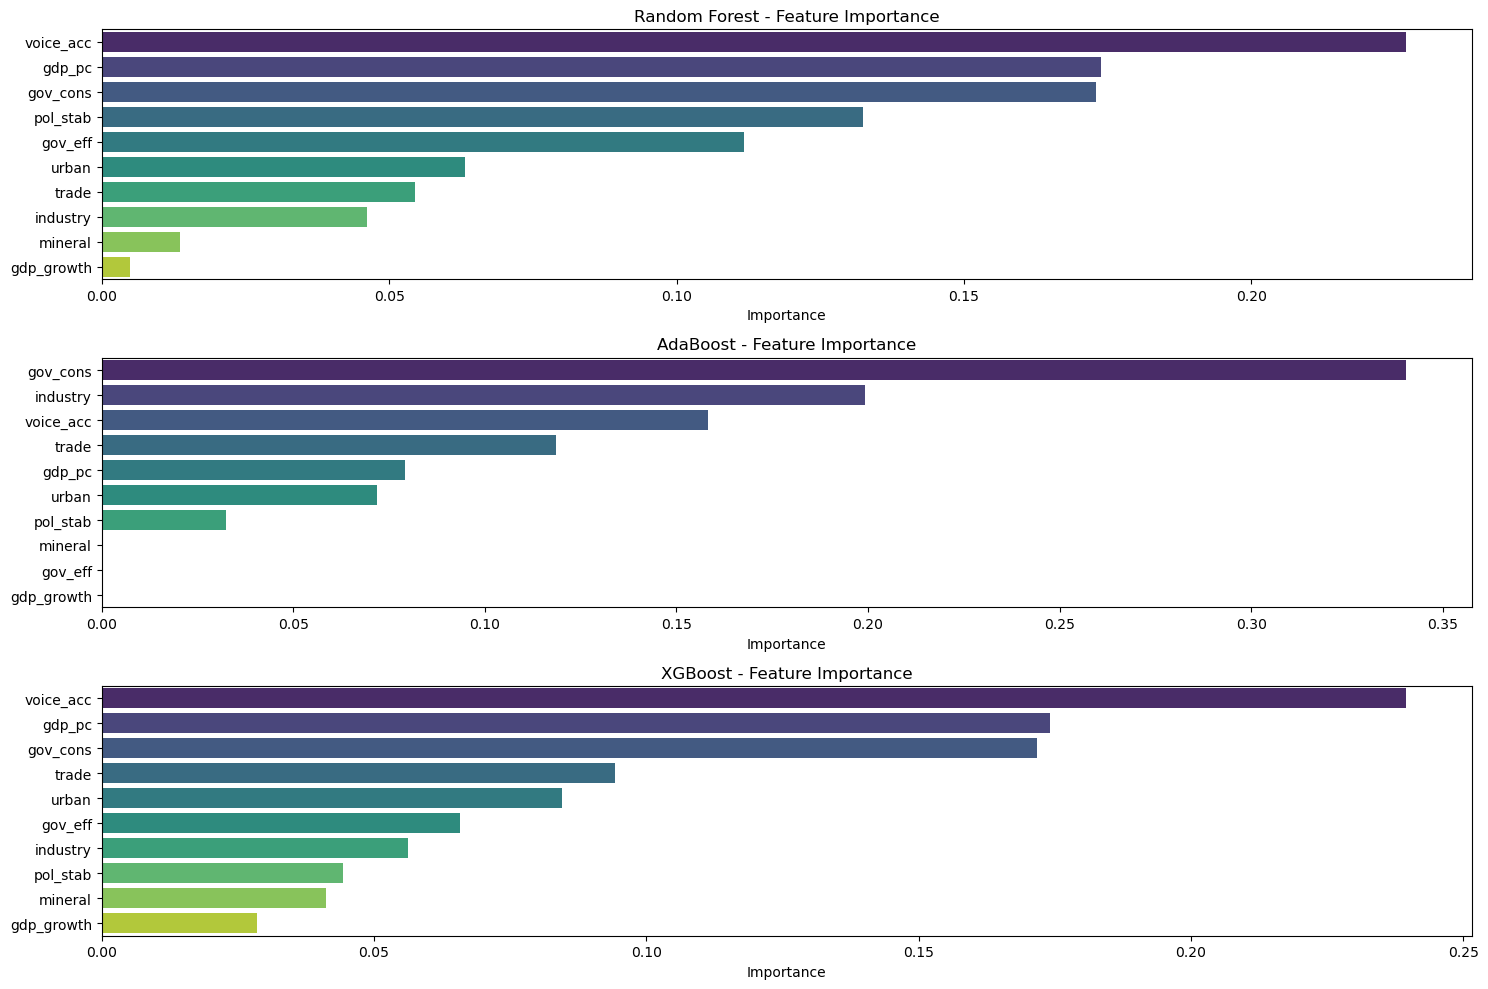


Random Forest - Top 5 Most Important Features:
voice_acc    0.2270
gdp_pc       0.1738
gov_cons     0.1729
pol_stab     0.1323
gov_eff      0.1116
dtype: float64

AdaBoost - Top 5 Most Important Features:
gov_cons     0.3405
industry     0.1991
voice_acc    0.1584
trade        0.1186
gdp_pc       0.0792
dtype: float64

XGBoost - Top 5 Most Important Features:
voice_acc    0.2396
gdp_pc       0.1742
gov_cons     0.1717
trade        0.0942
urban        0.0844
dtype: float32


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, roc_auc_score, classification_report)
from xgboost import XGBClassifier
import time

# ====================== LOAD & PREPARE DATA ======================
df = pd.read_csv('merged_environmental_taxes_and_controls.csv')

df = df.rename(columns={
    'Country': 'country',
    'environmental_taxes': 'env_tax',
    'Mineral rents (% of GDP)': 'mineral',
    'Government Effectiveness: Estimate': 'gov_eff',
    'GDP per capita (current US$)': 'gdp_pc',
    'Trade (% of GDP)': 'trade',
    'Industry (including construction), value added (% of GDP)': 'industry',
    'General government final consumption expenditure (% of GDP)': 'gov_cons',
    'Urban population (% of total population)': 'urban',
    'GDP growth (annual %)': 'gdp_growth',
    'Political Stability and Absence of Violence/Terrorism: Estimate': 'pol_stab',
    'Voice and Accountability: Estimate': 'voice_acc'
})

# Binary target (same as your classification tree)
df['high_env_tax'] = (df['env_tax'] > df['env_tax'].median()).astype(int)

features = ['mineral', 'gov_eff', 'gdp_pc', 'gdp_growth', 'gov_cons',
            'industry', 'trade', 'urban', 'pol_stab', 'voice_acc']

X = df[features]
y = df['high_env_tax']
groups = df['country']

# ====================== GROUP-AWARE TRAIN-TEST SPLIT ======================
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

print(f"Train countries: {df.iloc[train_idx]['country'].nunique()}")
print(f"Test countries:  {df.iloc[test_idx]['country'].nunique()}")

# ====================== 1. RANDOM FOREST ======================
rf = RandomForestClassifier(random_state=42, oob_score=True)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [10, 20],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(rf, rf_param_grid, cv=GroupKFold(n_splits=5), 
                       scoring='f1', n_jobs=-1)
start = time.time()
rf_grid.fit(X_train, y_train, groups=df.iloc[train_idx]['country'])
rf_time = time.time() - start

best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest ===")
print("Best params:", rf_grid.best_params_)
print(f"Training time: {rf_time:.1f} seconds")
print(f"OOB Score: {best_rf.oob_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, rf_pred):.1%}")
print(f"Test F1:       {f1_score(y_test, rf_pred):.4f}")
print(f"Test AUC:      {roc_auc_score(y_test, rf_prob):.4f}")

# ====================== 2. ADABOOST ======================
ada = AdaBoostClassifier(random_state=42)

ada_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.5, 1.0, 1.5]
}

ada_grid = GridSearchCV(ada, ada_param_grid, cv=GroupKFold(n_splits=5), 
                        scoring='f1', n_jobs=-1)
start = time.time()
ada_grid.fit(X_train, y_train, groups=df.iloc[train_idx]['country'])
ada_time = time.time() - start

best_ada = ada_grid.best_estimator_
ada_pred = best_ada.predict(X_test)
ada_prob = best_ada.predict_proba(X_test)[:, 1]

print("\n=== AdaBoost ===")
print("Best params:", ada_grid.best_params_)
print(f"Training time: {ada_time:.1f} seconds")
print(f"Test Accuracy: {accuracy_score(y_test, ada_pred):.1%}")
print(f"Test F1:       {f1_score(y_test, ada_pred):.4f}")
print(f"Test AUC:      {roc_auc_score(y_test, ada_prob):.4f}")

# ====================== 3. XGBOOST ======================
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_param_grid, cv=GroupKFold(n_splits=5), 
                        scoring='f1', n_jobs=-1)
start = time.time()
xgb_grid.fit(X_train, y_train, groups=df.iloc[train_idx]['country'])
xgb_time = time.time() - start

best_xgb = xgb_grid.best_estimator_
xgb_pred = best_xgb.predict(X_test)
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print("Best params:", xgb_grid.best_params_)
print(f"Training time: {xgb_time:.1f} seconds")
print(f"Test Accuracy: {accuracy_score(y_test, xgb_pred):.1%}")
print(f"Test F1:       {f1_score(y_test, xgb_pred):.4f}")
print(f"Test AUC:      {roc_auc_score(y_test, xgb_prob):.4f}")

# ====================== FEATURE IMPORTANCES PLOTS ======================
plt.figure(figsize=(15, 10))

models = {'Random Forest': best_rf, 'AdaBoost': best_ada, 'XGBoost': best_xgb}

for i, (name, model) in enumerate(models.items(), 1):
    imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    
    plt.subplot(3, 1, i)
    sns.barplot(
        x=imp.values, 
        y=imp.index, 
        hue=imp.index,          # <-- this fixes the warning
        palette='viridis',
        legend=False            # <-- this fixes the warning
    )
    plt.title(f'{name} - Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('')

plt.tight_layout()
plt.show()

# ====================== PRINT TOP 5 FEATURES FOR EACH MODEL ======================
for name, model in models.items():
    imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    print(f"\n{name} - Top 5 Most Important Features:")
    print(imp.head(5).round(4))

Feature importance analysis using tree-based machine learning models (Random Forest, AdaBoost, and XGBoost) reveals several insights not fully apparent in the linear regressions. Most notably, mineral rents (% of GDP) consistently rank among the least important predictors across all three models. In contrast, Voice and Accountability emerges as the single most important variable, followed closely by GDP per capita and general government consumption. These results suggest that democratic accountability and overall level of economic development play a larger role in determining environmental tax revenues than raw mineral dependence. Government Effectiveness ranks only moderately, indicating that the specific channel of bureaucratic competence may be less decisive than broader participatory institutions.While the OLS regressions showed a statistically significant negative interaction between mineral rents and government effectiveness, the machine learning models imply that any conditional effect of mineral dependence is relatively modest once non-linearities and interactions among development, trade openness, and institutional quality are accounted for. Overall, the ML analysis supports the view that institutional quality moderates resource dependence effects, but highlights Voice and Accountability — rather than Government Effectiveness alone — as the more critical dimension.

## 3.7 OLS vs ML

The OLS regressions and tree-based ensemble models (Random Forest, AdaBoost, and XGBoost) offer complementary insights into the determinants of environmental tax revenue (% of GDP).
In the OLS specifications, mineral rents (% of GDP) exhibit a negative and statistically significant coefficient in the benchmark model (−0.123*** ). After introducing the interaction with Government Effectiveness, the direct effect of mineral rents weakens, while the interaction term is negative and significant (−0.103***). This supports the hypothesis that stronger institutions moderate the adverse impact of mineral dependence. Government Effectiveness itself enters positively but loses significance in the fullest model due to multicollinearity among governance indicators.
In contrast, the feature importance rankings from the three tree-based models paint a different picture. Voice and Accountability consistently emerges as the most important predictor across all models, followed closely by GDP per capita and general government consumption (% of GDP). Mineral rents ranks near the bottom in every model, while Government Effectiveness shows only moderate importance. The models achieve solid predictive performance (test accuracy ≈ 83%, AUC 0.91–0.95).
From an econometric perspective, OLS imposes strong assumptions of linearity, additivity, and constant marginal effects. It estimates average partial effects and requires the researcher to manually specify interaction terms. Tree-based methods, being non-parametric, automatically capture complex non-linear relationships and higher-order interactions without explicit specification. They are also more robust to multicollinearity and provide a ranking of variables based on their actual contribution to predictive accuracy rather than average coefficients.
Economically, the OLS results align with the core hypothesis: mineral dependence tends to undermine environmental tax collection, but institutional quality can partially mitigate this effect. The tree-based models add valuable nuance by revealing that democratic accountability (Voice and Accountability) appears more powerful than bureaucratic effectiveness alone in sustaining environmental taxes. Once non-linear patterns and interactions among development, state capacity, and openness are accounted for, mineral rents plays a relatively minor role.
Overall, the regression trees extract extra information that linear models cannot easily reveal: the true relative importance of variables and the complex, non-linear ways in which institutions and economic development shape environmental policy outcomes. While OLS provides clean, interpretable average effects, the ML models offer richer predictive insight and highlight that participatory institutions may be the dominant channel.

## 3.8 Conclusion

This project examined whether mineral dependence undermines environmental fiscal policy and whether government effectiveness moderates this relationship. Using panel data for 63 countries over 2003–2020, I combined traditional econometric analysis with machine learning validation and supplementary enforcement data scraped from the EITI database.

The OLS regressions consistently showed a negative association between mineral rents and environmental tax revenue as a share of GDP. The introduction of an interaction term revealed that this negative effect is stronger in countries with weaker institutions, supporting the hypothesis that government effectiveness acts as a moderator. Machine learning models (Random Forest, AdaBoost, and XGBoost) provided additional nuance: while mineral rents ranked relatively low in predictive importance, Voice and Accountability emerged as the dominant institutional factor, followed by GDP per capita and government consumption. These results suggest that participatory institutions may matter more than pure bureaucratic competence in sustaining environmental taxation.

The scraped mining penalty data added a critical enforcement perspective missing from statutory tax measures. Highly mineral-dependent countries such as the Democratic Republic of Congo collected the largest absolute penalties, indicating that resource-rich economies do engage in ex-post enforcement when violations occur. However, the modest scale of penalties relative to mining sector size, combined with the concentration of enforcement activity in lower-effectiveness settings, highlights a persistent gap between policy design and implementation.

Overall, the findings support the central argument that mineral dependence tends to weaken environmental fiscal policy, but strong institutions—particularly those enhancing accountability—can partially mitigate this effect. Rather than an inevitable resource curse, the results point to institutional quality as a key lever for reconciling natural resource wealth with environmental sustainability. Future research could usefully explore non-linear thresholds and incorporate broader enforcement metrics to further unpack these mechanisms.

## References 

Barma, N. H., Kaiser, K., Le, T. M., & Viñuela, L. (2012). Rents to riches? The political economy of natural resource-led development. World Bank Publications. https://doi.org/10.1596/978-0-8213-8480-0

Chen, K., Qammar, R., Quddus, A., Lyu, N., & Alnafrah, I. (2024). Interlinking dynamics of natural resources, financial development, industrialization, and energy intensity: Implications for natural resources policy in emerging seven countries. Resources Policy, 90, Article 104809. https://doi.org/10.1016/j.resourpol.2024.104809

Collier, P., & Goderis, B. (2007). Commodity prices, growth, and the natural resource curse: Reconciling a conundrum (CSAE Working Paper No. 2007-15). Centre for the Study of African Economies, University of Oxford.

Dai, J., Hiung, E. Y. T., Destek, M. A., & Ahmed, Z. (2024). Green policymaking in top emitters: Assessing the consequences of external conflicts, trade globalization, and mineral resources on sustainable development. International Journal of Sustainable Development & World Ecology, 31(6), 653–667. https://doi.org/10.1080/13504509.2024.2319136

Danish, Ulucak, R., & Baloch, M. A. (2023). An empirical approach to the nexus between natural resources and environmental pollution: Do economic policy and environmental-related technologies make any difference? Resources Policy, 81, Article 103361. https://doi.org/10.1016/j.resourpol.2023.103361

Espin, J., & Perz, S. (2021). Environmental crimes in extractive activities: Explanations for low enforcement effectiveness in the case of illegal gold mining in Madre de Dios, Peru. The Extractive Industries and Society, 8(1), 331–339. https://doi.org/10.1016/j.exis.2020.11.012

Farzanegan, M. R., & Markwardt, G. (2018). Development and pollution in the Middle East and North Africa: Democracy matters. Journal of Policy Modeling, 40(2), 350–374. https://doi.org/10.1016/j.jpolmod.2018.01.005

Grossman, G. M., & Krueger, A. B. (1995). Economic growth and the environment. The Quarterly Journal of Economics, 110(2), 353–377. https://doi.org/10.2307/2118443

Luo, S., & Mabrouk, F. (2022). Nexus between natural resources, globalization and ecological sustainability in resource-rich countries: Dynamic role of green technology and environmental regulation. Resources Policy, 79, Article 103027. https://doi.org/10.1016/j.resourpol.2022.103027

Oyekola, O., Emediegwu, L. E., & Animashaun, J. O. (2024). Commodity windfalls, political regimes, and environmental quality. Energy Economics, 138, Article 107813. https://doi.org/10.1016/j.eneco.2024.107813

Paramati, S. R., Ummalla, M., & Apergis, N. (2016). The effect of foreign direct investment and stock market growth on clean energy use across a panel of emerging market economies. Energy Economics, 56, 29–41. https://doi.org/10.1016/j.eneco.2016.02.008

Shahbaz, M., Gozgor, G., Adom, P. K., & Hammoudeh, S. (2019). The technical decomposition of carbon emissions and the concerns about FDI and trade openness effects in the United States. Applied Economics, 51(31), 3391–3408. https://doi.org/10.1080/00036846.2019.1578850

Ulucak, R., Danish, & Ozcan, B. (2020). Relationship between energy consumption and environmental sustainability in OECD countries: The role of natural resources rents. Resources Policy, 69, Article 101803. https://doi.org/10.1016/j.resourpol.2020.101803

Wang, L., Vo, X. V., Shahbaz, M., & Ak, A. (2020). Globalization and carbon emissions: Is there any role of agriculture value-added, financial development, and natural resource rent in the aftermath of COP21? Journal of Environmental Management, 268, Article 110712. https://doi.org/10.1016/j.jenvman.2020.110712

Wang, H., & Li, J. (2024). Does oil, gas, and mineral rents reduce amid rising environmental policy stringency? Mediating role of financial development in G11 countries. Resources Policy, 91, Article 104878. https://doi.org/10.1016/j.resourpol.2024.104878

World Bank. (n.d.). World Development Indicators [Data set]. Retrieved March 13, 2026, from https://databank.worldbank.org/source/world-development-indicators